In [1]:
from pathlib import Path

def data_dir() -> Path:
    """หาโฟลเดอร์ datasets/ โดยไล่ขึ้นจาก cwd."""
    for p in (Path.cwd(), *Path.cwd().parents):
        if (p / "datasets").exists():
            return p / "datasets"
    raise SystemExit("ไม่พบโฟลเดอร์ datasets/ — เปิด JupyterLab จาก repo root (uv run jupyter lab)")

DATA = data_dir()

# # Solution — Module 6: Clustering
#
# **Dataset:** UCI *Air Quality* — De Vito, S., Massera, E., Piga, M., Martinotto, L., Di Francia, G. (2008); UCI ML Repository, https://doi.org/10.24432/C59K5F (CC BY 4.0) — `datasets/air_quality_uci.csv`

In [2]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

PALETTE = ["#264653", "#2a9d8f", "#e9c46a", "#f4a261", "#e76f51"]

FEATURES = ["PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)",
            "PT08.S4(NO2)", "PT08.S5(O3)", "T", "RH"]
SENSORS = FEATURES[:5]                      # เฉพาะ 5 ช่องเซนเซอร์

aq = pl.read_csv(DATA / "air_quality_uci.csv", separator=";", null_values="-200")
aq = aq.filter(pl.col("Date").is_not_null())
for c in ["CO(GT)", "C6H6(GT)", "T", "RH", "AH"]:
    aq = aq.with_columns(pl.col(c).str.replace(",", ".").cast(pl.Float64))
aq = aq.with_columns(
    (pl.col("Date") + " " + pl.col("Time")).str.to_datetime("%d/%m/%Y %H.%M.%S").alias("ts")
)
clean = aq.drop_nulls(FEATURES).with_row_index("row_id")
print(clean.shape)

X7 = clean.select(FEATURES).to_numpy().astype(float)
scaler = StandardScaler().fit(X7)
X7s = scaler.transform(X7)

# ค่าอ้างอิงจาก book.ipynb (7 คอลัมน์, k=4)
km7 = KMeans(n_clusters=4, n_init=10, random_state=42).fit(X7s)
sil7 = silhouette_score(X7s, km7.labels_)
print(f"7-feature, k=4 → silhouette = {sil7:.4f}")

(8991, 19)


7-feature, k=4 → silhouette = 0.2704


# ## ข้อ A1 — ตัด T/RH ออก: cluster จาก 5 ช่องเซนเซอร์เท่านั้น

In [3]:
X5 = clean.select(SENSORS).to_numpy().astype(float)
X5s = StandardScaler().fit_transform(X5)
km5 = KMeans(n_clusters=4, n_init=10, random_state=42).fit(X5s)
lab5 = km5.labels_
sil5 = silhouette_score(X5s, lab5)
print(f"5-feature, k=4 → silhouette = {sil5:.4f} (7-feature = {sil7:.4f})")

# เทียบองค์ประกอบ: regime จาก 5 ช่องกับ regime จาก 7 ช่อง ตรงกันแค่ไหน
import itertools
ct5 = pl.DataFrame(np.round(StandardScaler().fit(X5).inverse_transform(km5.cluster_centers_), 1),
                   schema=SENSORS).with_row_index("cluster")
with pl.Config(tbl_width_chars=220):
    print(ct5)

5-feature, k=4 → silhouette = 0.2864 (7-feature = 0.2704)
shape: (4, 6)
┌─────────┬─────────────┬───────────────┬──────────────┬──────────────┬─────────────┐
│ cluster ┆ PT08.S1(CO) ┆ PT08.S2(NMHC) ┆ PT08.S3(NOx) ┆ PT08.S4(NO2) ┆ PT08.S5(O3) │
│ ---     ┆ ---         ┆ ---           ┆ ---          ┆ ---          ┆ ---         │
│ u32     ┆ f64         ┆ f64           ┆ f64          ┆ f64          ┆ f64         │
╞═════════╪═════════════╪═══════════════╪══════════════╪══════════════╪═════════════╡
│ 0       ┆ 1185.7      ┆ 1058.8        ┆ 704.4        ┆ 1577.3       ┆ 1180.4      │
│ 1       ┆ 854.8       ┆ 614.2         ┆ 1213.6       ┆ 1122.2       ┆ 562.0       │
│ 2       ┆ 1457.5      ┆ 1369.0        ┆ 540.6        ┆ 1903.7       ┆ 1660.1      │
│ 3       ┆ 997.3       ┆ 818.8         ┆ 874.7        ┆ 1331.7       ┆ 849.7       │
└─────────┴─────────────┴───────────────┴──────────────┴──────────────┴─────────────┘


# **สรุปข้อ A1:** silhouette ของ 5 ช่อง (≈ 0.286) สูงกว่า 7 ช่อง (≈ 0.270) เล็กน้อย — การตัด T/RH ออกทำให้ก้อนข้อมูล "กลมกว่า" และแยกกันชัดขึ้นในเชิงเรขาคณิต แต่ **silhouette ไม่ใช่ตัวตัดสิน**: regime จาก 5 ช่องเซนเซอร์อย่างเดียวผสมสภาพอากาศเข้าด้วยกัน เราไม่สามารถบอกได้ว่า cluster ไหนคือ "กลางวันร้อน-แห้ง" หรือ "คืนเย็น" — เพราะ T/RH คือสิ่งที่ทำให้ regime อธิบายในภาษาของห้องปฏิบัติการได้ เป้าหมายของเราคือแผนสอบเทียบตามสภาพแวดล้อม จึงควรเก็บ T/RH ไว้แม้ silhouette จะต่ำลงนิดหน่อย (ต่างกัน ~0.015 ซึ่งเล็กมากเมื่อเทียบกับราคาของ "regime ที่ตีความไม่ได้")

# ## ข้อ A2 — k=3 หรือ k=5 จึงจะ "ถูก" กับงานสอบเทียบ

In [4]:
km3 = KMeans(n_clusters=3, n_init=10, random_state=42).fit(X7s)
km5b = KMeans(n_clusters=5, n_init=10, random_state=42).fit(X7s)
for name, km in [("k=3", km3), ("k=5", km5b)]:
    sil = silhouette_score(X7s, km.labels_)
    cent = scaler.inverse_transform(km.cluster_centers_)
    print(f"--- {name}: silhouette = {sil:.4f}")
    print(pl.DataFrame(np.round(cent, 1), schema=FEATURES).with_row_index("cluster"))

# โครงเวลาของ k=3 กับ k=5 (ชั่วโมงเฉลี่ยของแต่ละ cluster)
hours = clean["ts"].dt.hour().to_numpy()
for name, km in [("k=3", km3), ("k=5", km5b)]:
    print(name, "mean hour per cluster:",
          [round(float(hours[km.labels_ == c].mean()), 1) for c in range(km.n_clusters)])

--- k=3: silhouette = 0.2846
shape: (3, 8)
┌─────────┬─────────────┬───────────────┬──────────────┬──────────────┬─────────────┬──────┬──────┐
│ cluster ┆ PT08.S1(CO) ┆ PT08.S2(NMHC) ┆ PT08.S3(NOx) ┆ PT08.S4(NO2) ┆ PT08.S5(O3) ┆ T    ┆ RH   │
│ ---     ┆ ---         ┆ ---           ┆ ---          ┆ ---          ┆ ---         ┆ ---  ┆ ---  │
│ u32     ┆ f64         ┆ f64           ┆ f64          ┆ f64          ┆ f64         ┆ f64  ┆ f64  │
╞═════════╪═════════════╪═══════════════╪══════════════╪══════════════╪═════════════╪══════╪══════╡
│ 0       ┆ 1377.3      ┆ 1256.2        ┆ 583.5        ┆ 1754.1       ┆ 1525.0      ┆ 17.2 ┆ 55.3 │
│ 1       ┆ 1066.0      ┆ 966.2         ┆ 814.4        ┆ 1568.5       ┆ 932.8       ┆ 27.2 ┆ 33.9 │
│ 2       ┆ 950.1       ┆ 722.4         ┆ 1007.4       ┆ 1192.4       ┆ 772.0       ┆ 12.8 ┆ 56.1 │
└─────────┴─────────────┴───────────────┴──────────────┴──────────────┴─────────────┴──────┴──────┘


--- k=5: silhouette = 0.2440
shape: (5, 8)
┌─────────┬─────────────┬───────────────┬──────────────┬──────────────┬─────────────┬──────┬──────┐
│ cluster ┆ PT08.S1(CO) ┆ PT08.S2(NMHC) ┆ PT08.S3(NOx) ┆ PT08.S4(NO2) ┆ PT08.S5(O3) ┆ T    ┆ RH   │
│ ---     ┆ ---         ┆ ---           ┆ ---          ┆ ---          ┆ ---         ┆ ---  ┆ ---  │
│ u32     ┆ f64         ┆ f64           ┆ f64          ┆ f64          ┆ f64         ┆ f64  ┆ f64  │
╞═════════╪═════════════╪═══════════════╪══════════════╪══════════════╪═════════════╪══════╪══════╡
│ 0       ┆ 937.5       ┆ 790.4         ┆ 960.2        ┆ 1407.3       ┆ 714.2       ┆ 24.4 ┆ 38.2 │
│ 1       ┆ 1113.5      ┆ 912.0         ┆ 760.5        ┆ 1342.4       ┆ 1087.4      ┆ 12.7 ┆ 61.8 │
│ 2       ┆ 1156.5      ┆ 1086.6        ┆ 733.0        ┆ 1694.7       ┆ 1102.9      ┆ 28.4 ┆ 32.2 │
│ 3       ┆ 1449.4      ┆ 1341.6        ┆ 543.0        ┆ 1859.0       ┆ 1642.3      ┆ 17.4 ┆ 55.8 │
│ 4       ┆ 881.9       ┆ 626.6         ┆ 1163.5       ┆ 

# **สรุปข้อ A2:** k=3 ได้ silhouette สูงกว่า (≈ 0.285 เทียบ ≈ 0.244) และ centroid สามตัวก็ตั้งชื่อได้ครบ (เช้า-ค่ำมลพิษสูง 17 °C / ร้อน-แห้งกลางวัน 27 °C / คืนเย็นอากาศสะอาด 13 °C) — ส่วน k=5 silhouette ตกลงมากและก้อนที่เพิ่มมาให้ข้อมูลใหม่น้อย: มันแยก regime "ร้อน-แห้งกลางวัน" ออกเป็นสองก้อน (28.4 °C/32% vs 24.4 °C/38%) และเพิ่มก้อนเย็นสุด 10.6 °C ที่ตั้งชื่อต่างจากก้อน 12.7 °C ได้ยาก
#
# คำตอบที่ป้องกันตัวได้: **k=3 หรือ k=4 ล้วนแย้งได้ — k=5 แย่กว่าทั้งสองเกณฑ์** ถ้าเลือก k=3 จะได้แผนสอบเทียบสามสภาวะที่ silhouette ดีที่สุดในกลุ่ม 3–5; ถ้าเลือก k=4 จะได้การแยก "ดึกชื้น" ออกจาก "คืนลึก" ซึ่งมีประโยชน์เมื่อความชื้นคือความเสี่ยงหลักของเซนเซอร์ สิ่งที่ห้ามทำคือยึด k จาก silhouette ลำพัง (มันให้ k=2 ซึ่งหยาบเกินงาน) หรือบวม k ขึ้นเรื่อย ๆ โดยไม่มีชื่อ regime มากำกับ

# ## ข้อ B1 — ชั่วโมงนอก regime: ใช้ DBSCAN เป็นเครื่องตรวจ

noise = 54 ชั่วโมง (0.60%)
ก้อนเล็ก (สมาชิก < 100): labels [np.int64(1)] รวม 17 ชั่วโมง


/tmp/ipykernel_45325/912471620.py:21: UserWarning: Glyph 3594 (\N{THAI CHARACTER CHO CHANG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45325/912471620.py:21: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45325/912471620.py:21: UserWarning: Glyph 3650 (\N{THAI CHARACTER SARA O}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45325/912471620.py:21: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45325/912471620.py:21: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45325/912471620.py:21: UserWarning: Glyph 3607 (\N{THAI CHARACTER THO THAHAN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45325/912471620.py:21: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans

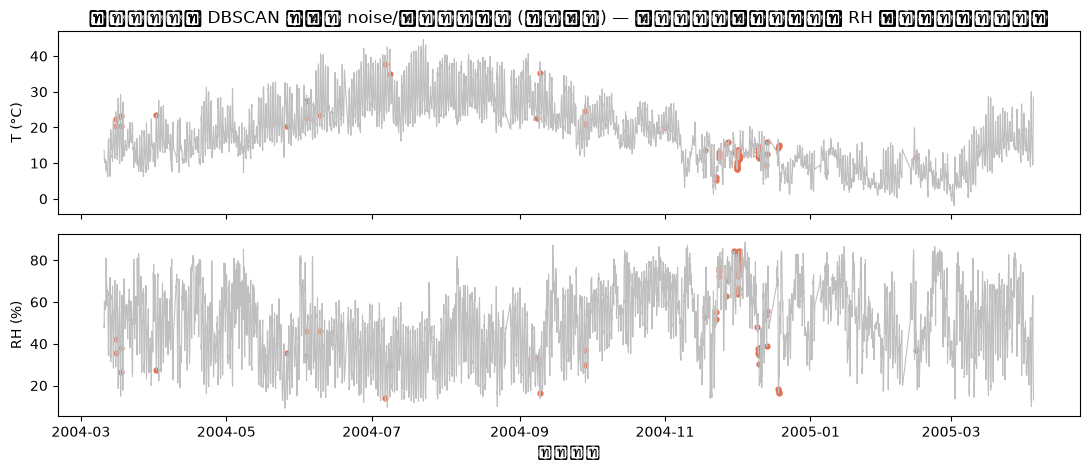

RH เฉลี่ยของชั่วโมง anomaly: 57.5 % เทียบค่ากลางข้อมูลทั้งหมด 49.6 %


In [5]:
db = DBSCAN(eps=1.0, min_samples=10).fit(X7s)
lab = db.labels_
n_noise = int((lab == -1).sum())
small_ids = [c for c, n in zip(*np.unique(lab[lab >= 0], return_counts=True)) if n < 100]
n_small = int(np.isin(lab, small_ids).sum())
print(f"noise = {n_noise} ชั่วโมง ({n_noise / len(lab) * 100:.2f}%)")
print(f"ก้อนเล็ก (สมาชิก < 100): labels {small_ids} รวม {n_small} ชั่วโมง")

anomaly = lab == -1
anomaly |= np.isin(lab, small_ids)          # รวมก้อนเล็กเข้ารายชื่อ "ชั่วโมงควรตรวจ"

fig, axes = plt.subplots(2, 1, figsize=(11, 4.8), sharex=True)
axes[0].plot(clean["ts"], clean["T"], color="0.75", lw=0.8)
axes[0].scatter(clean.filter(anomaly)["ts"], clean.filter(anomaly)["T"], s=12, color="#e76f51")
axes[0].set_ylabel("T (°C)")
axes[0].set_title("ชั่วโมงที่ DBSCAN ตีว่า noise/ก้อนเล็ก (จุดส้ม) — ส่วนใหญ่คือคืนที่ RH พุ่งสูงผิดปกติ")
axes[1].plot(clean["ts"], clean["RH"], color="0.75", lw=0.8)
axes[1].scatter(clean.filter(anomaly)["ts"], clean.filter(anomaly)["RH"], s=12, color="#e76f51")
axes[1].set_ylabel("RH (%)")
axes[1].set_xlabel("เวลา")
fig.tight_layout()
plt.show()

print("RH เฉลี่ยของชั่วโมง anomaly:", round(float(clean.filter(anomaly)["RH"].mean()), 1),
      "% เทียบค่ากลางข้อมูลทั้งหมด", round(float(clean["RH"].median()), 1), "%")

# **สรุปข้อ B1:** ได้ noise 54 ชั่วโมง (0.60%) บวกก้อนเล็ก 17 ชั่วโมง (คืน 1–2 ธ.ค. 2004, RH เฉลี่ย ~80%) — รวมเป็นรายชื่อ 71 ชั่วโมงที่ควรตรวจซ้ำ และจากภาพจะเห็นว่า noise กระจุกผิดปกติ: **26 จาก 54 ชั่วโมงมาจากสี่วันของเดือนธันวาคม 2004 เท่านั้น** (1, 10, 13, 18 ธ.ค.) — คืนหนาวที่ความชื้นสูงกว่าค่ากลางของข้อมูล (RH เฉลี่ยของกลุ่ม anomaly 57.5% เทียบค่ากลาง 49.6%) เซนเซอร์ metal-oxide ไวต่อความชื้นสูง ชั่วโมงพวกนี้จึงหลุดจากทุก regime ปกติ เหตุผลน่าจะเป็น **สภาพแวดล้อมจริงที่ผิดปกติ** (หมอก/ฝน) ไม่ใช่ข้อผิดพลาดของข้อมูล — ทางที่ถูกคือทำเครื่องหมายไว้แล้วตรวจสอบกับบันทึกอุตุนิยมวิทยา ไม่ใช่ลบทิ้งเงียบ ๆ

# ## ข้อ B2 — อ่าน loadings: ช่องไหนขยับพร้อมกัน

EV ratio: [0.814 0.103 0.049]
shape: (2, 6)
┌─────────────┬───────────────┬──────────────┬──────────────┬─────────────┬─────┐
│ PT08.S1(CO) ┆ PT08.S2(NMHC) ┆ PT08.S3(NOx) ┆ PT08.S4(NO2) ┆ PT08.S5(O3) ┆ PC  │
│ ---         ┆ ---           ┆ ---          ┆ ---          ┆ ---         ┆ --- │
│ f64         ┆ f64           ┆ f64          ┆ f64          ┆ f64         ┆ str │
╞═════════════╪═══════════════╪══════════════╪══════════════╪═════════════╪═════╡
│ 0.469       ┆ 0.479         ┆ -0.43        ┆ 0.39         ┆ 0.461       ┆ PC1 │
│ -0.091      ┆ 0.09          ┆ 0.433        ┆ 0.838        ┆ -0.305      ┆ PC2 │
└─────────────┴───────────────┴──────────────┴──────────────┴─────────────┴─────┘


/tmp/ipykernel_45325/4238781630.py:15: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45325/4238781630.py:15: UserWarning: Glyph 3627 (\N{THAI CHARACTER HO HIP}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45325/4238781630.py:15: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45325/4238781630.py:15: UserWarning: Glyph 3651 (\N{THAI CHARACTER SARA AI MAIMUAN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45325/4238781630.py:15: UserWarning: Glyph 3586 (\N{THAI CHARACTER KHO KHAI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45325/4238781630.py:15: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_45325/4238781630.py:15: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) De

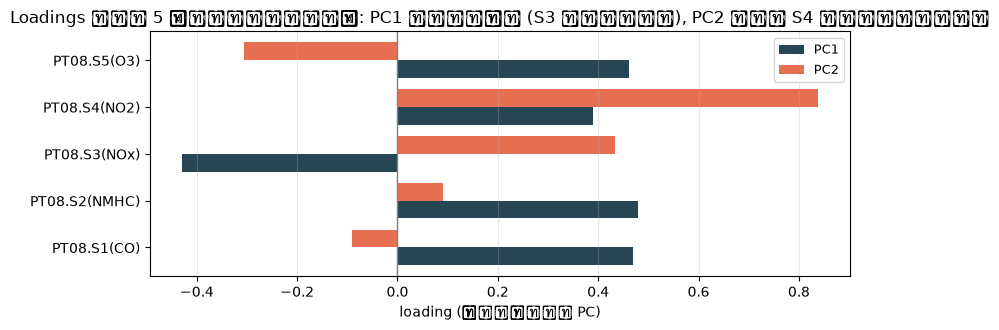


สหสัมพันธ์ของ 5 ช่อง (ยืนยัน):
shape: (5, 6)
┌─────────────┬───────────────┬──────────────┬──────────────┬─────────────┬───────────────┐
│ PT08.S1(CO) ┆ PT08.S2(NMHC) ┆ PT08.S3(NOx) ┆ PT08.S4(NO2) ┆ PT08.S5(O3) ┆ feat          │
│ ---         ┆ ---           ┆ ---          ┆ ---          ┆ ---         ┆ ---           │
│ f64         ┆ f64           ┆ f64          ┆ f64          ┆ f64         ┆ str           │
╞═════════════╪═══════════════╪══════════════╪══════════════╪═════════════╪═══════════════╡
│ 1.0         ┆ 0.892964      ┆ -0.771938    ┆ 0.682881     ┆ 0.899324    ┆ PT08.S1(CO)   │
│ 0.892964    ┆ 1.0           ┆ -0.796703    ┆ 0.777254     ┆ 0.880578    ┆ PT08.S2(NMHC) │
│ -0.771938   ┆ -0.796703     ┆ 1.0          ┆ -0.538468    ┆ -0.796569   ┆ PT08.S3(NOx)  │
│ 0.682881    ┆ 0.777254      ┆ -0.538468    ┆ 1.0          ┆ 0.591144    ┆ PT08.S4(NO2)  │
│ 0.899324    ┆ 0.880578      ┆ -0.796569    ┆ 0.591144     ┆ 1.0         ┆ PT08.S5(O3)   │
└─────────────┴───────────────┴───

In [6]:
pca5 = PCA().fit(X5s)
print("EV ratio:", np.round(pca5.explained_variance_ratio_[:3], 3))
print(pl.DataFrame(np.round(pca5.components_[:2], 3), schema=SENSORS).with_columns(pl.Series("PC", ["PC1", "PC2"])))

fig, ax = plt.subplots(figsize=(8.5, 3.4))
ypos = np.arange(len(SENSORS))
ax.barh(ypos - 0.19, pca5.components_[0], height=0.38, color="#264653", label="PC1")
ax.barh(ypos + 0.19, pca5.components_[1], height=0.38, color="#e76f51", label="PC2")
ax.set_yticks(ypos, SENSORS)
ax.axvline(0, color="gray", lw=1)
ax.set_xlabel("loading (น้ำหนักใน PC)")
ax.set_title("Loadings ของ 5 ช่องเซนเซอร์: PC1 รวมพลัง (S3 สวนทาง), PC2 แยก S4 ออกจากพวก")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis="x")
fig.tight_layout()
plt.show()

print("\nสหสัมพันธ์ของ 5 ช่อง (ยืนยัน):")
with pl.Config(tbl_width_chars=200):
    print(clean.select(SENSORS).corr().with_columns(pl.Series("feat", SENSORS)))

# **สรุปข้อ B2:** PC1 กลืนความแปรปรวน 81% ของข้อมูล 5 ช่อง — S1, S2, S5 มี loading บวกใหญ่ใกล้กัน (+0.47, +0.48, +0.46) และ S4 บวกตามหลัง (+0.39) ขณะที่ **S3 ติดลบหนัก (−0.43)** → ช่อง S1–S2–S5 (และ S4 รอง) **ขยับพร้อมกัน** ส่วน S3 (NOx) **สวนทางเสมอ** — สหสัมพันธ์ยืนยัน: S1–S2 = 0.89, S1–S5 = 0.90 แต่ S3 กับทุกช่องติดลบ (−0.54 ถึง −0.80) ส่วน PC2 มี S4 โดดออก (+0.84) — ช่อง NO2 มีพฤติกรรมเฉพาะตัวที่โหมดร่วมจับไม่หมด เมื่อเซนเซอร์หลายช่องวิ่งตามกันถึงระดับ 0.8–0.9 ข้อมูลจึงมีข้อมูลสารสนเทศซ้ำซ้อนสูง (multicollinearity) — เหตุผลที่หนึ่งเซนเซอร์ "โหมดร่วม" แทนทุกช่องได้ และที่โมเดลสอบเทียบควรระวังการอ่านน้ำหนักรายช่อง

# ## ข้อ B3 — คำตอบ
#
# **1) ถ้าต้องเลือก regime เดียวสำหรับใบรับรอง:** ควรเลือกช่วงที่เครื่องใช้งานจริงมากที่สุด — จากแผนภาพเวลาใน book.ipynb คือช่วง **เย็นปานกลาง T ≈ 13–18 °C, RH ≈ 50–60%** (regime เย็นครองพื้นที่มากที่สุดของปี) แต่ใบรับรองต้องเขียนข้อจำกัดกำกับเสมอ: ค่าที่รับรองใช้ได้ **เฉพาะช่วง T/RH ที่สอบเทียบ** — การใช้งานนอกช่วง (กลางวันร้อน 28 °C หรือคืนชื้น >75% RH) คือ extrapolation ในทางเมโทรโลยี (บทเรียน Module 3) ค่าคลาดเคลื่อนจริงจะโตขึ้นหลายเท่าและไม่มีสิทธิ์อ้างตัวเลขในใบรับรอง
#
# **2) ก้อนเล็ก 17 ชั่วโมง + noise 54 ชั่วโมง:** เลือก **(ค) เก็บไว้ตรวจเป็นกรณีพิเศษ** — เหตุผลเชิงเมโทรโลยี: (ก) ลบทิ้ง = ทิ้งหลักฐานว่าเครื่องมีสภาพใช้งานที่โมเดลเราไม่ครอบคลุม และซ่อนความเสี่ยงไว้ในงานวัดจริง; (ข) รวมเข้า regime ใกล้สุด = ปลอมให้ข้อมูลผิดปกติดูปกติ ทำให้โมเดลของ regime นั้นเสียเพี้ยนโดยไม่รู้ตัว — ชั่วโมงหมอก RH ~80% ในคืนอุณหภูมิ 10 °C คือสภาวะที่ความชื้นกัดเซนเซอร์แรงที่สุด งานสอบเทียบที่ดีต้อง **ระบุขอบเขตการใช้งานและแยกสภาวะผิดปกติออกจากการประเมินความแม่น** มากกว่าจะกลืนมันเข้าค่าเฉลี่ย